<a href="https://colab.research.google.com/github/josevargasmercado02/Proyectos_fisica_computacional/blob/main/Caso2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modos Normales de una Cuerda Vibrante con Densidad de Masa Variable

*Un estudio mediante diferencias finitas y el solucionador de valores propios de Jacobi del problema generalizado de valores propios para una cuerda no homogénea.*

## Marco Teórico

Una cuerda de longitud $L$ bajo una tensión constante $T$, con densidad de masa $\mu(x)$ y extremos fijos, obedece la ecuación de onda unidimensional con coeficientes variables:

$$\mu(x)\,\frac{\partial^2 u}{\partial t^2} = T\,\frac{\partial^2 u}{\partial x^2}, \qquad u(0,t)=u(L,t)=0 .$$

Al buscar los modos normales $u(x,t)=X(x)\cos(\omega t)$ se obtiene un problema de valores propios de Sturm-Liouville:

$$-T\,X''(x) = \omega^2\,\mu(x)\,X(x).$$

**Discretización.** Con $N$ nodos interiores, $x_i = i\,\Delta x$, $\Delta x = L/(N+1)$, y una diferencia central de segundo orden, el problema se convierte en el problema matricial de valores propios generalizado

$$\mathbf{A}\,\mathbf{X} = \omega^2\,\mathbf{M}\,\mathbf{X}, \qquad \mathbf{A}=\frac{T}{\Delta x^2} \begin{pmatrix} 2 & -1 & & \\ -1 & 2 & \ddots & \\  & \ddots & \ddots & -1 \\  & & -1 & 2 \end{pmatrix}, \qquad \mathbf{M}=\mathrm{diag}\big(\mu(x_1),\dots,\mu(x_N)\big).$$

**Reducción a un problema estándar simétrico.** Definiendo $\mathbf{Y}=\mathbf{M}^{1/2}\mathbf{X}$ y
$\mathbf{C}=\mathbf{M}^{-1/2}\,\mathbf{A}\,\mathbf{M}^{-1/2}$. Entonces

$$\mathbf{C}\,\mathbf{Y} = \omega^2\,\mathbf{Y},$$

donde $\mathbf{C}$ es simétrica real, por lo que sus valores propios son reales y positivos, y sus vectores propios son ortogonales. Los modos físicos se recuperan como $\mathbf{X}=\mathbf{M}^{-1/2}\mathbf{Y}$.

**Método de Jacobi.** $\mathbf{C}$ se diagonaliza mediante una secuencia de rotaciones planas $\mathbf{Q}_{pq}(\theta)$ que anulan el elemento de mayor magnitud fuera de la diagonal en cada paso:

$$\mathbf{C}^{(k+1)} = \mathbf{Q}^{T}\,\mathbf{C}^{(k)}\,\mathbf{Q}, \qquad \tan 2\theta = \frac{2\,C_{pq}}{C_{pp}-C_{qq}} .$$

El producto acumulado $\mathbf{V}=\prod \mathbf{Q}$ contiene los vectores propios, y la diagonal de la matriz convergida contiene a $\omega_n^2$.

**Prueba de consistencia.** Para una densidad uniforme, $\omega_n = \dfrac{n\pi}{L}\sqrt{T/\mu}$, y el error de diferencias finitas escala como $\mathcal{O}(\Delta x^2)$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [ ]:
# Parámetros
L = 1.0     # Largo de la cuerda
T = 1.0     # Tensión
mu1 = 1.0   # Densidad de masa 1
mu2 = 2.0   # Densidad de masa 2
N = 3       # Número de nodos interiores

In [ ]:
def construir_matrices(L, T, mu_vector, N):
    dx = L / (N + 1) # Separación entre nodos

    # Vector de densidades y matriz M (ahora recibe mu_vector directamente)
    M = np.diag(mu_vector)

    # Construcción de la matriz A
    d_p = 2.0 * np.ones(N) # Diagonal principal
    d_s = -1.0 * np.ones(N - 1) # Diagonal secundaria
    A = (T / (dx**2)) * (np.diag(d_p) + np.diag(d_s, k=1) + np.diag(d_s, k=-1))

    # Matriz D y matriz simétrica C
    D = np.diag(1.0 / np.sqrt(mu_vector))
    C = D @ A @ D

    return C, D

def metodo_jacobi(C_in, epsilon=1e-8, N_max=20000):
    N = C_in.shape[0] # Tamaño de la matriz
    C = C_in.copy()   # Copia para no alterar la matriz original
    V = np.eye(N)     # Matriz acumuladora de vectores propios (identidad inicial)

    for k in range(N_max):
        # Optimización: Buscar exclusivamente el valor máximo absoluto por fuera de la diagonal
        # utilizando la parte triangular superior de la matriz simétrica
        C_upper = np.triu(np.abs(C), k=1)
        idx = np.argmax(C_upper)
        p, q = np.unravel_index(idx, C.shape)

        max_val = np.abs(C[p, q])

        # Criterio de parada: si el máximo es casi cero, la matriz ya es diagonal
        if max_val < epsilon:
            break

        # Calcular el ángulo de rotación theta
        if C[p, p] == C[q, q]:
            theta = (np.pi / 4.0) * np.sign(C[p, q]) # Evitar división por cero
        else:
            theta = 0.5 * np.arctan(2.0 * C[p, q] / (C[p, p] - C[q, q]))

        # Construir la matriz de rotación ortogonal Q
        Q = np.eye(N)
        Q[p, p] = np.cos(theta)
        Q[q, q] = np.cos(theta)
        Q[p, q] = -np.sin(theta)
        Q[q, p] = np.sin(theta)

        # Actualizar C (se va diagonalizando) y V (acumula los vectores propios)
        C = Q.T @ C @ Q
        V = V @ Q

    valores_propios = np.diag(C) # La diagonal final contiene los valores propios
    return valores_propios, V

def resolver_cuerda(L, T, mu_vector, N):
    # 1. Construir matrices
    C, D = construir_matrices(L, T, mu_vector, N)

    # 2. Valores y vectores propios del problema transformado
    valores_propios, Y = metodo_jacobi(C)

    # 3. Ordenar valores y vectores propios de menor a mayor
    indices_ordenados = np.argsort(valores_propios)
    valores_propios = valores_propios[indices_ordenados]
    Y = Y[:, indices_ordenados]

    # 4. Cálculo de frecuencias naturales
    frecuencias_angulares = np.sqrt(valores_propios)

    # 5. Recuperar modos físicos X = D * Y
    X_interiores = D @ Y

    # 6. Incorporar condiciones de frontera (X_0 = 0 y X_N+1 = 0)
    # Creamos una matriz de (N+2) filas y N columnas. Cada columna es un modo completo.
    X_completos = np.zeros((N + 2, N))
    X_completos[1:-1, :] = X_interiores

    return valores_propios, frecuencias_angulares, X_completos


## Experimento Numérico

Estudiamos una cuerda de longitud $L=1$ bajo una tensión $T=1$ con extremos fijos y ejecutamos tres análisis, todos construidos sobre el mismo solucionador (`solve_on_grid`):

1. **Caso base (malla gruesa).** Una densidad que aumenta linealmente $\mu(x)=\mu_1+(\mu_2-\mu_1)\,x/L$ con $\mu_1=1$, $\mu_2=2$ y solo $N=3$ nodos interiores. Imprimimos las frecuencias angulares y las formas completas de los modos, y verificamos el solucionador comparándolo con LAPACK.
2. **Análisis de convergencia.** Refinamos la malla desde $N=3$ hasta $N=100$ y rastreamos $\omega_1,\omega_2,\omega_3$. Las frecuencias deberían converger como $\mathcal{O}(\Delta x^2)$.
3. **Efecto del perfil de densidad.** En una malla fina ($N=50$) comparamos los primeros nueve modos para el perfil lineal contra un perfil en escalón ($\mu=1$ para $x<L/2$, $\mu=4$ en el resto). Las formas de los modos se normalizan a una amplitud máxima unitaria. Las regiones más pesadas deberían mostrar longitudes de onda locales más cortas y amplitudes menores, ya que la velocidad de propagación de la onda es $c(x)=\sqrt{T/\mu(x)}$.

In [ ]:
# Ejecución inicial
x_ini = np.arange(1, N + 1) * (L / (N + 1))
mu_ini = mu1 + ((mu2 - mu1) / L) * x_ini
_, omegas, modos = resolver_cuerda(L, T, mu_ini, N)

print("Frecuencias angulares (omega_n):")
for i, w in enumerate(omegas):
    print(f"Modo {i+1}: {w:.4f}")

print("\nModos de vibración completos (cada columna es un modo, incluyendo extremos fijos):")
print(np.round(modos, 4)) # Redondeamos a 4 decimales

Frecuencias angulares (omega_n):
Modo 1: 2.4926
Modo 2: 4.6188
Modo 3: 6.1378

Modos de vibración completos (cada columna es un modo, incluyendo extremos fijos):
[[ 0.      0.      0.    ]
 [ 0.3781 -0.562   0.5841]
 [ 0.5727 -0.1873 -0.551 ]
 [ 0.4337  0.562   0.2598]
 [ 0.      0.      0.    ]]


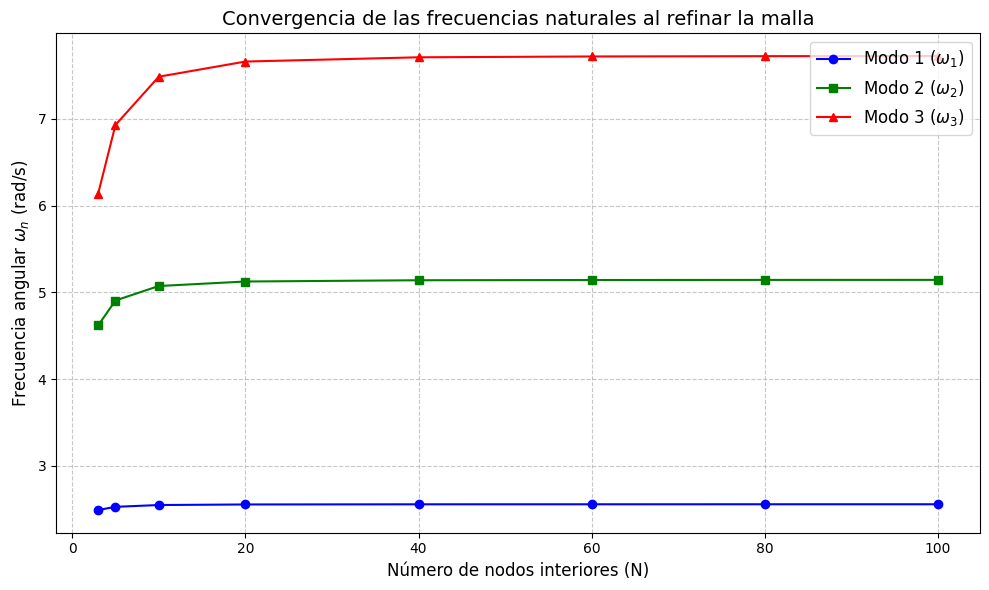

In [ ]:
# Análisis de convergencia
# Definir los tamaños de malla a evaluar
N_valores = [3, 5, 10, 20, 40, 60, 80, 100]

# Listas para almacenar la evolución de las frecuencias
omega_1 = []
omega_2 = []
omega_3 = []

# Iterar sobre cada valor de N
for N_test in N_valores:
    x_test = np.arange(1, N_test + 1) * (L / (N_test + 1))
    mu_test = mu1 + ((mu2 - mu1) / L) * x_test
    _, omegas_test, _ = resolver_cuerda(L, T, mu_test, N_test)

    # Guardamos las primeras tres frecuencias (índices 0, 1 y 2)
    omega_1.append(omegas_test[0])
    omega_2.append(omegas_test[1])
    omega_3.append(omegas_test[2])

# Graficar los resultados de convergencia
plt.figure(figsize=(10, 6))
plt.plot(N_valores, omega_1, marker='o', linestyle='-', color='b', label=r'Modo 1 ($\omega_1$)')
plt.plot(N_valores, omega_2, marker='s', linestyle='-', color='g', label=r'Modo 2 ($\omega_2$)')
plt.plot(N_valores, omega_3, marker='^', linestyle='-', color='r', label=r'Modo 3 ($\omega_3$)')
plt.title('Convergencia de las frecuencias naturales al refinar la malla', fontsize=14)
plt.xlabel('Número de nodos interiores (N)', fontsize=12)
plt.ylabel(r'Frecuencia angular $\omega_n$ (rad/s)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

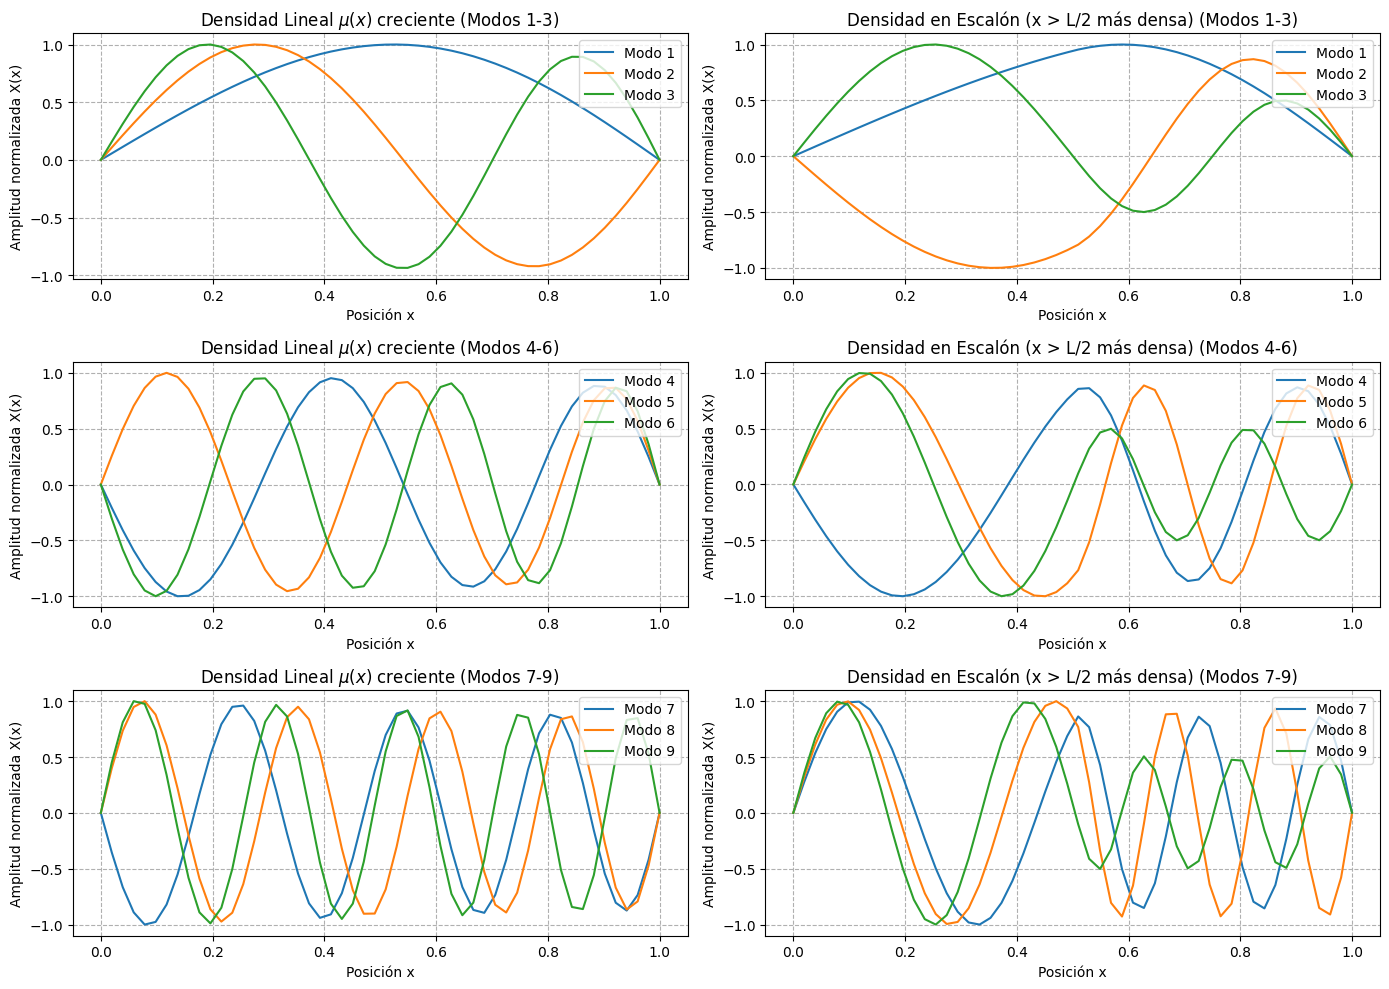

In [ ]:
# Modos de vibración y variación de la densidad
# Parámetros para la visualización de alta resolución
N_plot = 50
dx_plot = L / (N_plot + 1)
x_interiores = np.arange(1, N_plot + 1) * dx_plot
x_full = np.linspace(0, L, N_plot + 2) # Eje x completo incluyendo los nodos fijos

# Caso A: Densidad lineal (el problema original)
mu_lineal = mu1 + ((mu2 - mu1) / L) * x_interiores

# Caso B: Densidad en escalón (Mitad izquierda ligera, mitad derecha pesada)
mu_escalon = np.where(x_interiores < L/2, 1.0, 4.0)

_, _, modos_lin = resolver_cuerda(L, T, mu_lineal, N_plot)
_, _, modos_esc = resolver_cuerda(L, T, mu_escalon, N_plot)

# Normalizamos la amplitud para que las gráficas espaciales se vean limpias
for i in range(N_plot):
    max_amp_lin = np.max(np.abs(modos_lin[:, i]))
    max_amp_esc = np.max(np.abs(modos_esc[:, i]))
    if max_amp_lin > 0:
        modos_lin[:, i] = modos_lin[:, i] / max_amp_lin
    if max_amp_esc > 0:
        modos_esc[:, i] = modos_esc[:, i] / max_amp_esc

# Gráficas estáticas comparativas extendidas (Modos 1 a 6)
fig, axs = plt.subplots(3, 2, figsize=(14, 10))

# Fila 0: Modos 1, 2, 3
for i in range(3):
    axs[0, 0].plot(x_full, modos_lin[:, i], label=f'Modo {i+1}')
    axs[0, 1].plot(x_full, modos_esc[:, i], linestyle='-', label=f'Modo {i+1}')

# Fila 1: Modos 4, 5, 6
for i in range(3, 6):
    axs[1, 0].plot(x_full, modos_lin[:, i], label=f'Modo {i+1}')
    axs[1, 1].plot(x_full, modos_esc[:, i], linestyle='-', label=f'Modo {i+1}')

# Fila 2: Modos 7, 8, 9
for i in range(6, 9):
    axs[2, 0].plot(x_full, modos_lin[:, i], label=f'Modo {i+1}')
    axs[2, 1].plot(x_full, modos_esc[:, i], linestyle='-', label=f'Modo {i+1}')

# Configuración de los títulos
axs[0, 0].set_title(r'Densidad Lineal $\mu(x)$ creciente (Modos 1-3)')
axs[0, 1].set_title(r'Densidad en Escalón (x > L/2 más densa) (Modos 1-3)')
axs[1, 0].set_title(r'Densidad Lineal $\mu(x)$ creciente (Modos 4-6)')
axs[1, 1].set_title(r'Densidad en Escalón (x > L/2 más densa) (Modos 4-6)')
axs[2, 0].set_title(r'Densidad Lineal $\mu(x)$ creciente (Modos 7-9)')
axs[2, 1].set_title(r'Densidad en Escalón (x > L/2 más densa) (Modos 7-9)')

# Aplicar etiquetas y grilla a todos los subplots
for ax in axs.flat:
    ax.set_xlabel('Posición x')
    ax.set_ylabel('Amplitud normalizada X(x)')
    ax.grid(linestyle='--')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
